In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
df = pd.read_csv("encoded_attrition_data.csv")
df.head()

,age,seniority,tenure,monthly_income,satisfaction_score,work_life_balance,overtime,commute_distance,promotion_last_5yrs,performance_score,trg_hrs_last_year,attrition,department_Engineering,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,42,3,9,9866,4,1,0,24.5,1,4,19,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,36,3,7,8958,3,3,0,10.0,0,2,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,44,4,16,11716,4,3,0,4.0,0,4,13,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,53,4,30,17061,5,3,0,7.1,0,3,20,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,35,2,4,5738,2,3,0,8.4,0,2,15,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [2]:
y = df['attrition']
X = df.drop('attrition', axis=1)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [6]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [7]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.63      0.75      1819
           1       0.14      0.61      0.23       181

    accuracy                           0.63      2000
   macro avg       0.54      0.62      0.49      2000
weighted avg       0.87      0.63      0.71      2000



In [10]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,overtime,0.702865
16,department_Operations,0.317630
17,department_Sales,0.244512
15,department_Marketing,0.240971
14,department_IT,0.097824
11,department_Engineering,0.085707
12,department_Finance,0.013047
0,age,0.008847
10,trg_hrs_last_year,0.008236
7,commute_distance,0.007649


In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
rf_pred = rf.predict(X_test)
print(accuracy_score(y_test, rf_pred))

0.8635


In [15]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1819
           1       0.20      0.17      0.19       181

    accuracy                           0.86      2000
   macro avg       0.56      0.55      0.56      2000
weighted avg       0.85      0.86      0.86      2000



In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                   Feature  Importance
3           monthly_income    0.158199
7         commute_distance    0.145217
0                      age    0.105834
4       satisfaction_score    0.104093
2                   tenure    0.103095
10       trg_hrs_last_year    0.094686
5        work_life_balance    0.067663
9        performance_score    0.040664
1                seniority    0.040630
6                 overtime    0.038591
11  department_Engineering    0.014258
17        department_Sales    0.013964
8      promotion_last_5yrs    0.013398
15    department_Marketing    0.013086
16   department_Operations    0.012897
14           department_IT    0.011562
13           department_HR    0.011409
12      department_Finance    0.010753


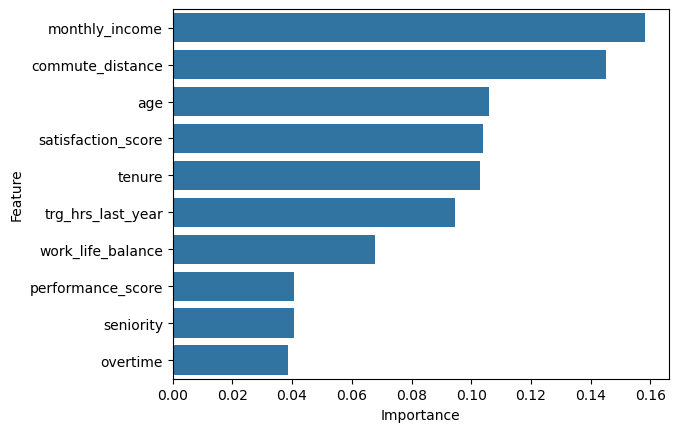

In [17]:
import piplite
await piplite.install('seaborn')
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.show()

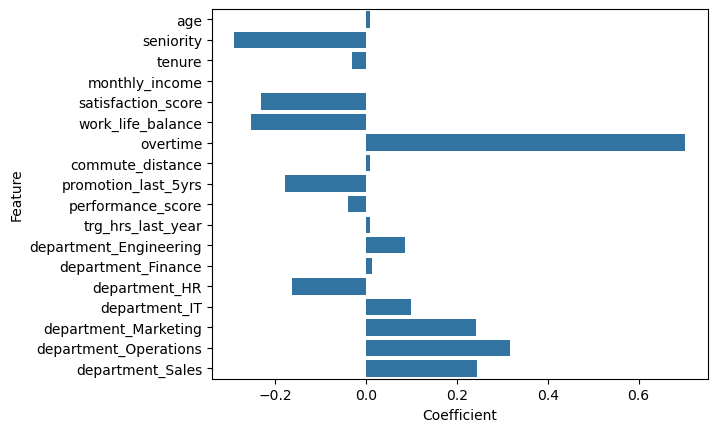

In [18]:
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.show()